# 決定木を用いた飲食店推薦アルゴリズムの提案

## 1. データの読み込み

In [189]:
import numpy as np
import json
from Users import GetLabels

user1_ratings, user2_ratings, user3_ratings= GetLabels.getLabels()

with open('Restaurants/Features.json', 'r', encoding='utf-8') as f:
    features = json.load(f)

feature_names = [
        "中華", "居酒屋", "ダイニングバー・バル", "和食", 
        "お好み焼き・もんじゃ", "韓国料理", "イタリアン・フレンチ", 
        "焼肉・ホルモン", "洋食", "アジア・エスニック料理", 
        "創作料理", "各国料理", "ラーメン","予算","個室", "喫煙","wifi",
        "カード", "駐車場", "総合評価"
    ]

#numpy形式に変換
features_np = np.array(features)
user1_ratings_np = np.array(user1_ratings)
user2_ratings_np = np.array(user2_ratings)
user3_ratings_np = np.array(user3_ratings)

In [190]:
# ユーザー名
user_names = ['User1', 'User2', 'User3']

# 各モデルの名前
model_names = ["Decision Tree", "Logistic Regression", "k-NN"]

#結果を格納する辞書
results = {
    "User1": {
        "Random": {"Precision": []},
        "Decision Tree": {"Accuracy": [], "Precision": [], "Recall": [], "F1": []},
        "Logistic Regression": {"Accuracy": [], "Precision": [], "Recall": [], "F1": []},
        "k-NN": {"Accuracy": [], "Precision": [], "Recall": [], "F1": []}
    },
    "User2": {
        "Random": {"Precision": []},
        "Decision Tree": {"Accuracy": [], "Precision": [], "Recall": [], "F1": []},
        "Logistic Regression": {"Accuracy": [], "Precision": [], "Recall": [], "F1": []},
        "k-NN": {"Accuracy": [], "Precision": [], "Recall": [], "F1": []}
    },
    "User3": {
        "Random": {"Precision": []},
        "Decision Tree": {"Accuracy": [], "Precision": [], "Recall": [], "F1": []},
        "Logistic Regression": {"Accuracy": [], "Precision": [], "Recall": [], "F1": []},
        "k-NN": {"Accuracy": [], "Precision": [], "Recall": [], "F1": []}
    }  
}

## 2. 10フォールド交差検証
### 目的
- 決定木を用いた手法の汎化性能を評価するため.

User1


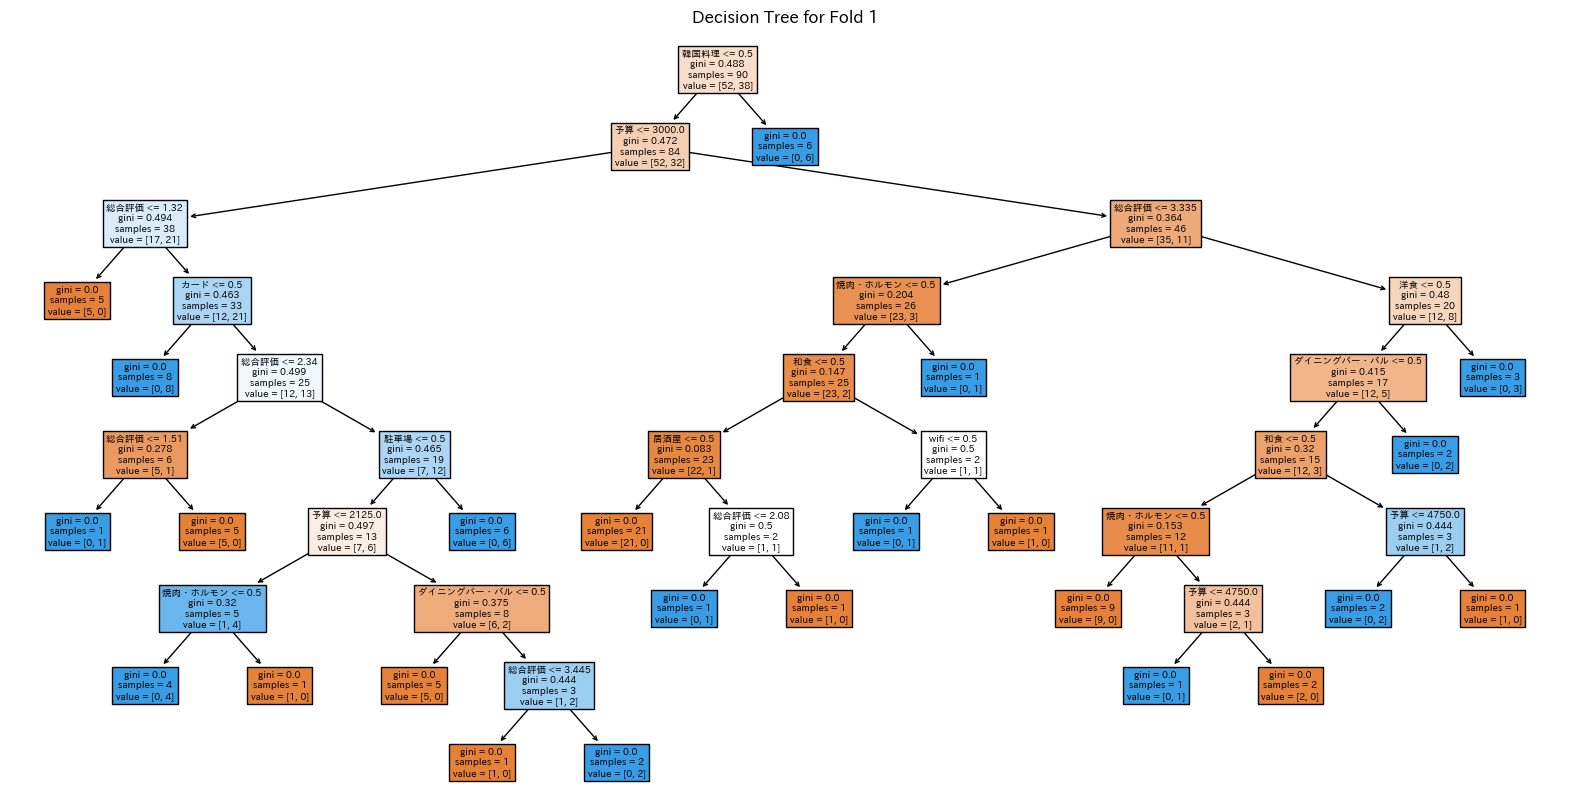

Mean Precision across all folds: 0.675
Mean Recall across all folds: 0.6093650793650793
Mean Random Precision across all folds: 0.44000000000000006

User2


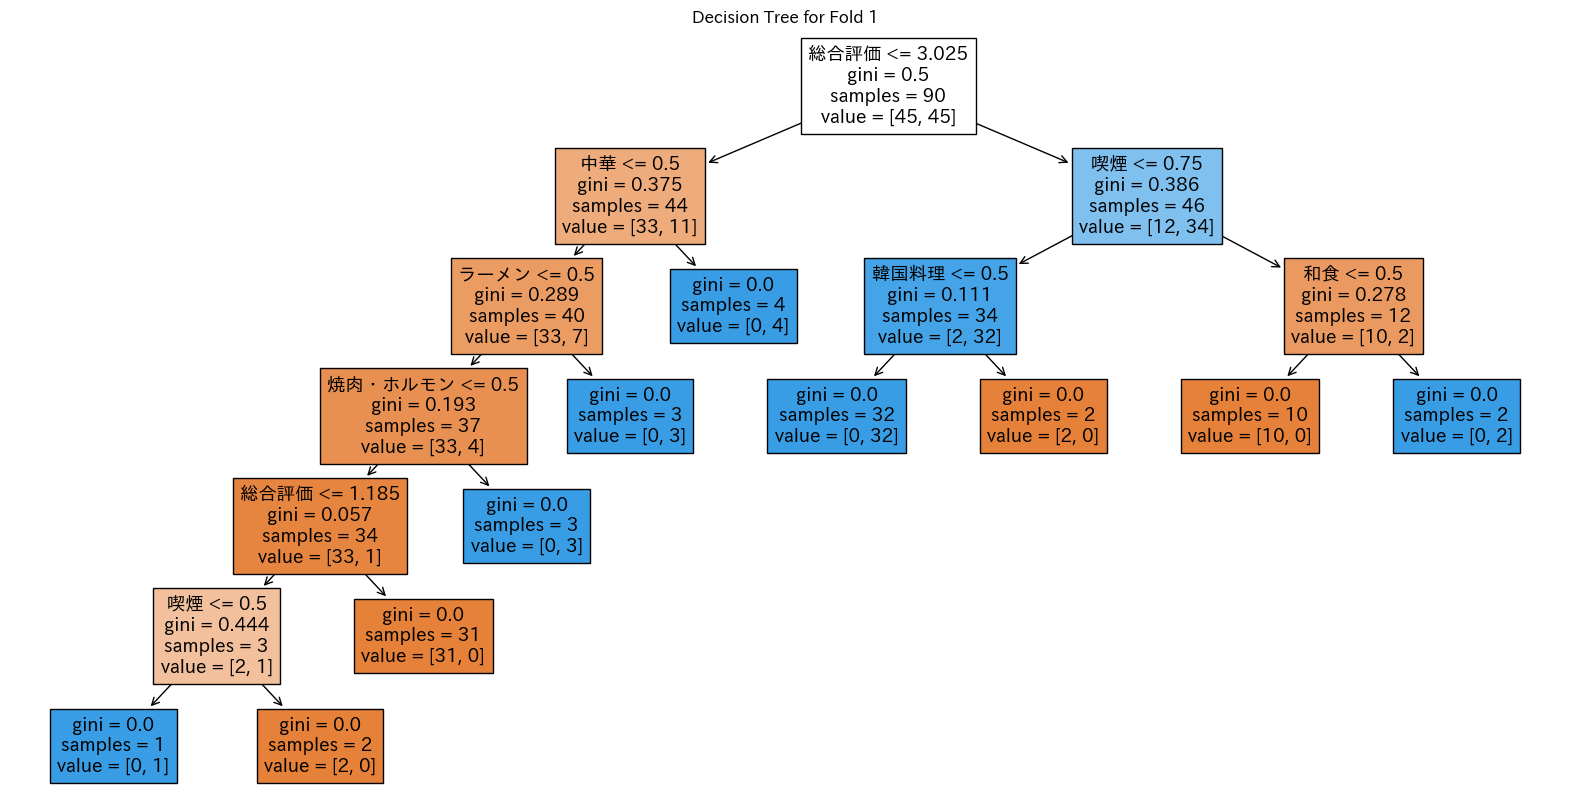

Mean Precision across all folds: 1.0
Mean Recall across all folds: 0.93
Mean Random Precision across all folds: 0.48

User3


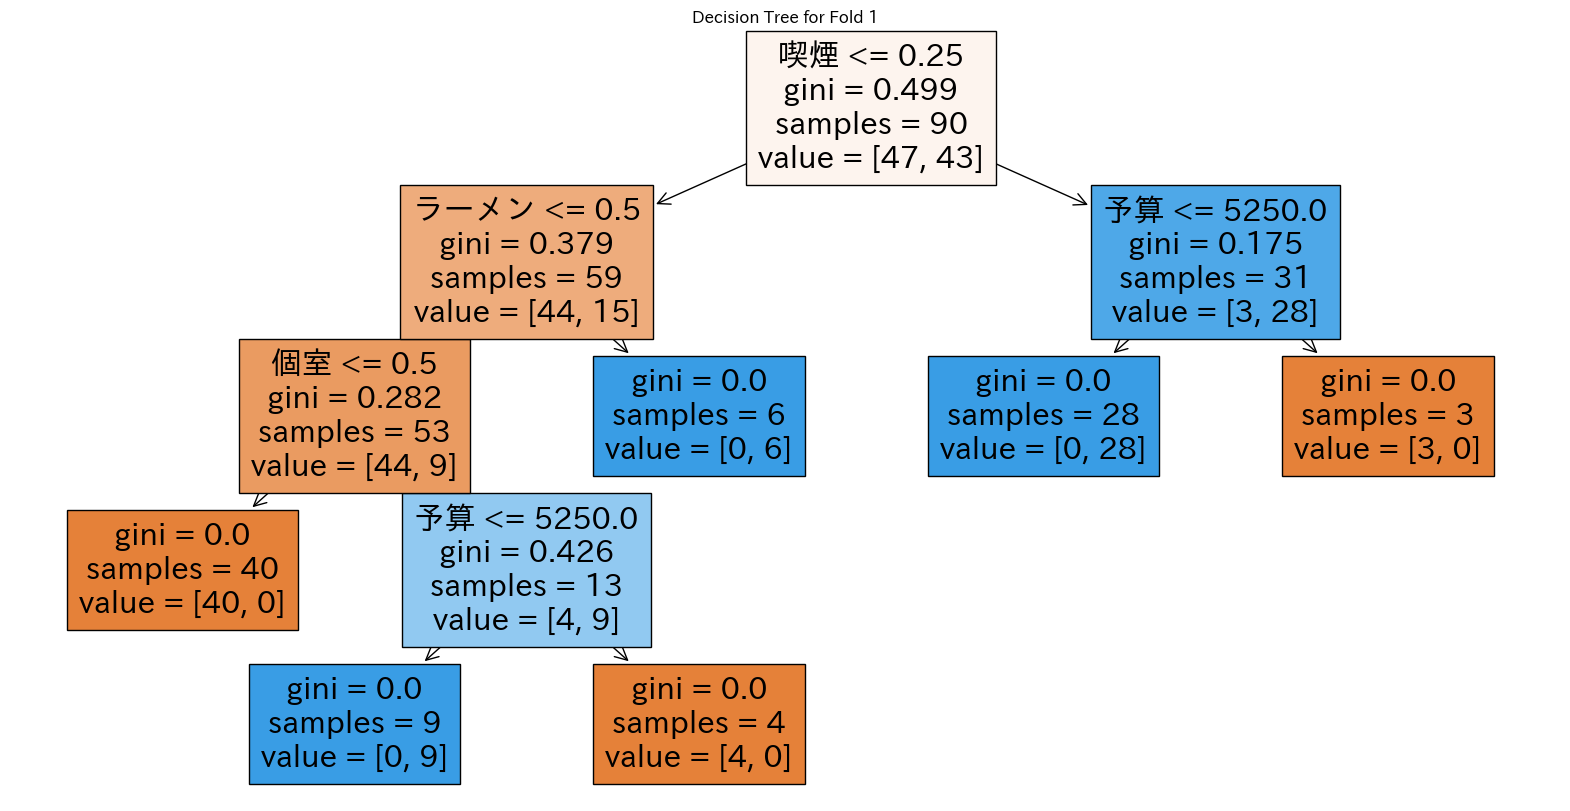

Mean Precision across all folds: 0.95
Mean Recall across all folds: 1.0
Mean Random Precision across all folds: 0.49000000000000005



In [191]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import japanize_matplotlib

 # KFoldインスタンスを初期化
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# NumPy配列をリスト形式の文字列に変換する関数
def array_to_list_string(array):
    formatted_array = []
    for elem in array:
        if np.isclose(elem, np.round(elem)):
            # np.iscloseで浮動小数点数が整数に近いか確認し、整数に変換
            formatted_array.append(str(int(np.round(elem))))
        else:
            # 浮動小数点数はそのままの形式で追加
            formatted_array.append(str(elem))
    return '[' + ', '.join(formatted_array) + ']'

def crossValidation(user_ratings_np, user_name):
    # ランダム手法の適合率を格納するリスト
    random_precisions = []

    # フォールド番号を1から始めるためのカウンター
    fold_counter = 1

    # KFoldで分割されたインデックスを使ってループ
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成します。
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user_ratings_np[train_index], user_ratings_np[test_index]

        # 決定木の分類器を作成し、トレーニングデータにフィット
        classifier = DecisionTreeClassifier(random_state=42)
        classifier.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = classifier.predict(X_test)

        # 適合率を計算し、リストに追加
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions, zero_division=0)
        recall = recall_score(y_test, predictions, zero_division=0)
        f1 = f1_score(y_test, predictions)
        
        # 再現率を計算し、リストに追加
        results[user_name]["Decision Tree"]["Accuracy"].append(accuracy)
        results[user_name]["Decision Tree"]["Precision"].append(precision)
        results[user_name]["Decision Tree"]["Recall"].append(recall)
        results[user_name]["Decision Tree"]["F1"].append(f1)

        # テストセットに含まれる陽性クラスの割合を計算し、リストに追加
        positive_class_ratio = np.mean(y_test)
        results[user_name]["Random"]["Precision"].append(positive_class_ratio)

        # 決定木のプロット
        if fold_counter == 1: 
            plt.figure(figsize=(20,10))
            plot_tree(classifier, filled=True, feature_names=feature_names)
            plt.title(f'Decision Tree for Fold {fold_counter}')
            plt.show()
        
        # 次のフォールドへのカウンターを増やす
        fold_counter += 1

    # 全フォールドでの平均正解率を出力
    mean_precision = np.mean(results[user_name]["Decision Tree"]["Precision"])
    mean_recall = np.mean(results[user_name]["Decision Tree"]["Recall"])
    mean_random_precisions = np.mean(results[user_name]["Random"]["Precision"])
    print(f'Mean Precision across all folds: {mean_precision}')
    print(f'Mean Recall across all folds: {mean_recall}')
    print(f'Mean Random Precision across all folds: {mean_random_precisions}\n')

    return random_precisions

print("User1")
random1_predisions = crossValidation(user1_ratings_np, "User1")
print("User2")
random2_predisions= crossValidation(user2_ratings_np, "User2")
print("User3")
random3_predisions = crossValidation(user3_ratings_np, "User3")

### 結果
- 全てのユーザーにおいて, ランダム手法よりも平均適合率が良いことが分かった.

## 3. 訓練データを増やした適合率と再現率の推移
### 目的
- 訓練データを増やした際に, どの程度性能が上がるかどうかを調べる.

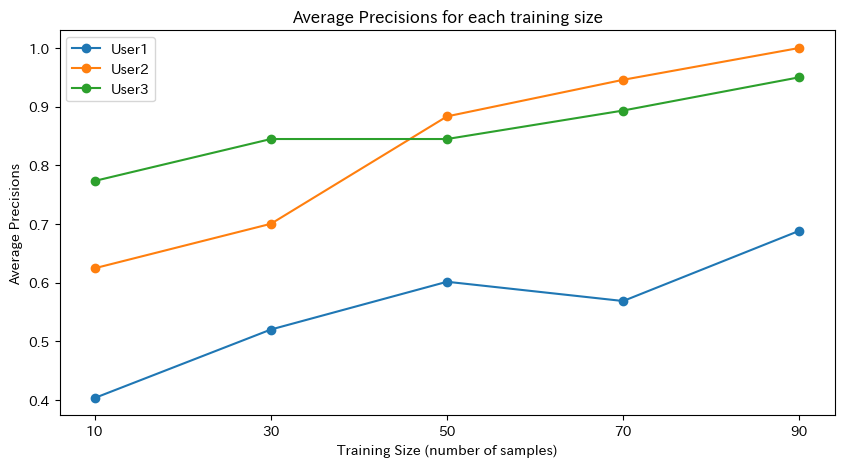

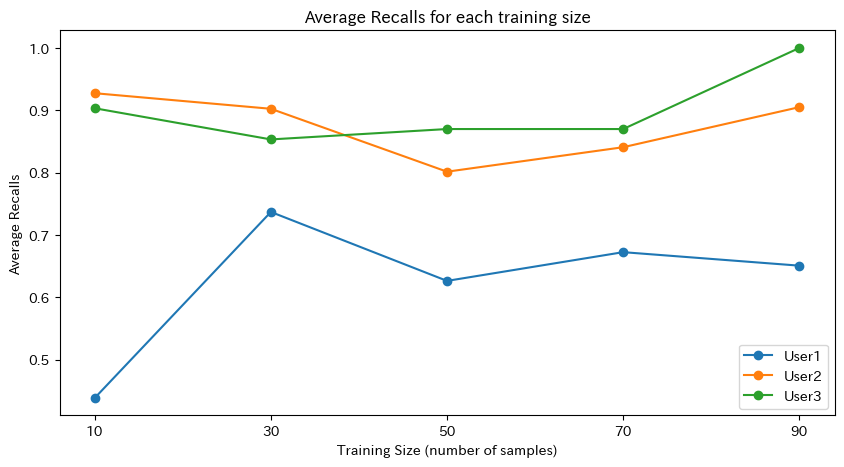

In [192]:
# 指定された訓練データのサイズ
training_sizes = [10, 30, 50, 70, 90]
def train(user_ratings_np):
    
    mean_precisions = {size: [] for size in training_sizes}
    mean_recalls = {size: [] for size in training_sizes}

    for train_index, test_index in kf.split(features_np):
        # テストデータを固定
        X_test, y_test = features_np[test_index], user_ratings_np[test_index]

        for size in training_sizes:
            # 訓練データを指定されたサイズで取得
            X_train = features_np[train_index[:size]]
            y_train = user_ratings_np[train_index[:size]]

            # モデルを訓練
            classifier = DecisionTreeClassifier(random_state=0)
            classifier.fit(X_train, y_train)

            # テストデータに対する予測
            predictions = classifier.predict(X_test)

            # 適合率を計算
            precision = precision_score(y_test, predictions, zero_division=0)
            # 再現率を計算
            recall = recall_score(y_test, predictions, zero_division=0)

            # スコアをリストに追加
            mean_precisions[size].append(precision)
            mean_recalls[size].append(recall)

    # 各訓練サイズについて平均スコアを計算
    final_precisions = [np.mean(mean_precisions[size]) for size in training_sizes]
    final_recalls = [np.mean(mean_recalls[size]) for size in training_sizes]

    return final_precisions, final_recalls

user1_final_precisions, user1_final_recalls = train(user1_ratings_np)
user2_final_precisions, user2_final_recalls = train(user2_ratings_np)
user3_final_precisions, user3_final_recalls = train(user3_ratings_np)

# 適合率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, user1_final_precisions, label='User1', marker='o')
plt.plot(training_sizes, user2_final_precisions, label='User2', marker='o')
plt.plot(training_sizes, user3_final_precisions, label='User3', marker='o')
plt.title('Average Precisions for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Precisions')
plt.xticks(training_sizes)
plt.legend()
plt.show()

# 再現率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, user1_final_recalls, label='User1', marker='o')
plt.plot(training_sizes, user2_final_recalls, label='User2', marker='o')
plt.plot(training_sizes, user3_final_recalls, label='User3', marker='o')
plt.title('Average Recalls for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Recalls')
plt.xticks(training_sizes)
plt.legend()
plt.show()


### 結果
- 訓練データが増えれば, 性能が上がるということが分かった

## 4. 他の手法との比較
- ロジスティック回帰を用いた手法, k-NNを用いた手法と性能を比較する

### 目的
- より分かりやすいアルゴリズムの評価にすること.

In [193]:
from sklearn.linear_model import LogisticRegression

def crossValidation(user_ratings_np, user_name):
    # 各モデルに対して交差検証を行う
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user_ratings_np[train_index], user_ratings_np[test_index]

        # ロジスティック回帰を訓練
        model = LogisticRegression(random_state=42,max_iter=500)
        model.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = model.predict(X_test)

        # 精度と適合率を計算し、リストに追加
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions)
        recall = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)
        
        results[user_name]["Logistic Regression"]["Accuracy"].append(accuracy)
        results[user_name]["Logistic Regression"]["Precision"].append(precision)
        results[user_name]["Logistic Regression"]["Recall"].append(recall)
        results[user_name]["Logistic Regression"]["F1"].append(f1)

crossValidation(user1_ratings_np, "User1")
crossValidation(user2_ratings_np, "User2")
crossValidation(user3_ratings_np, "User3")

In [194]:
from sklearn.neighbors import KNeighborsClassifier

def crossValidation(user_ratings_np, user_name):
    # 各モデルに対して交差検証を行う
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user_ratings_np[train_index], user_ratings_np[test_index]

        # ロジスティック回帰を訓練
        model = KNeighborsClassifier()
        model.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = model.predict(X_test)

        # 精度と適合率を計算し、リストに追加
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions)
        recall = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)
        
        results[user_name]["k-NN"]["Accuracy"].append(accuracy)
        results[user_name]["k-NN"]["Precision"].append(precision)
        results[user_name]["k-NN"]["Recall"].append(recall)
        results[user_name]["k-NN"]["F1"].append(f1)

crossValidation(user1_ratings_np, "User1")
crossValidation(user2_ratings_np, "User2")
crossValidation(user3_ratings_np, "User3")

User1
Decision Tree
Mean Accuracy: 0.71, Mean Precision: 0.675, Mean Recall: 0.6093650793650793, Mean_F1: 0.6232034632034632

Logistic Regression
Mean Accuracy: 0.6599999999999999, Mean Precision: 0.6333333333333333, Mean Recall: 0.5863492063492064, Mean_F1: 0.5699800199800198

k-NN
Mean Accuracy: 0.59, Mean Precision: 0.5123809523809524, Mean Recall: 0.4485714285714285, Mean_F1: 0.4552380952380952

User2
Decision Tree
Mean Accuracy: 0.96, Mean Precision: 1.0, Mean Recall: 0.93, Mean_F1: 0.9597979797979799

Logistic Regression
Mean Accuracy: 0.76, Mean Precision: 0.758095238095238, Mean Recall: 0.7930952380952381, Mean_F1: 0.7510972360972362

k-NN
Mean Accuracy: 0.6, Mean Precision: 0.6028571428571429, Mean Recall: 0.5745238095238095, Mean_F1: 0.5642568542568542

User3
Decision Tree
Mean Accuracy: 0.99, Mean Precision: 0.95, Mean Recall: 1.0, Mean_F1: 0.9666666666666666

Logistic Regression
Mean Accuracy: 0.9200000000000002, Mean Precision: 0.9216666666666666, Mean Recall: 0.8990476190

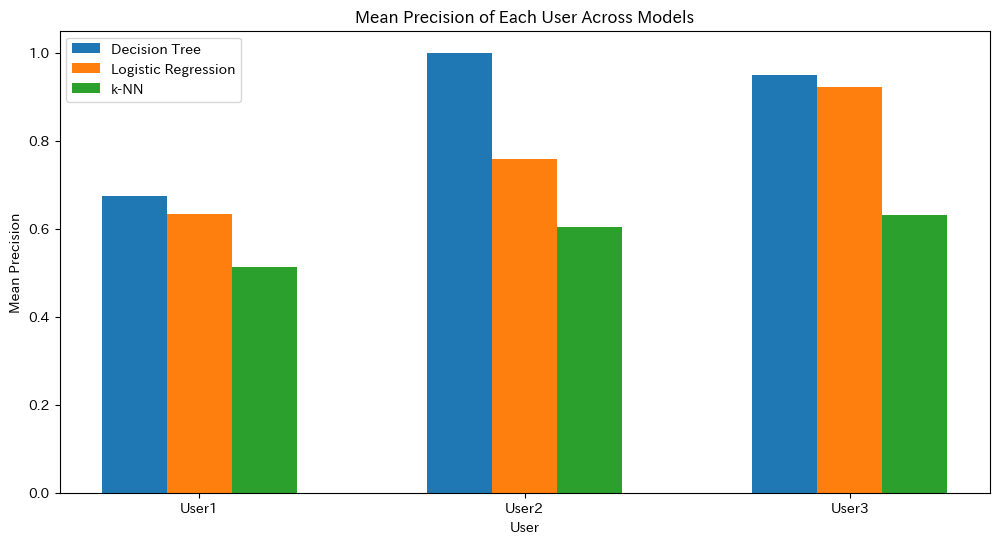

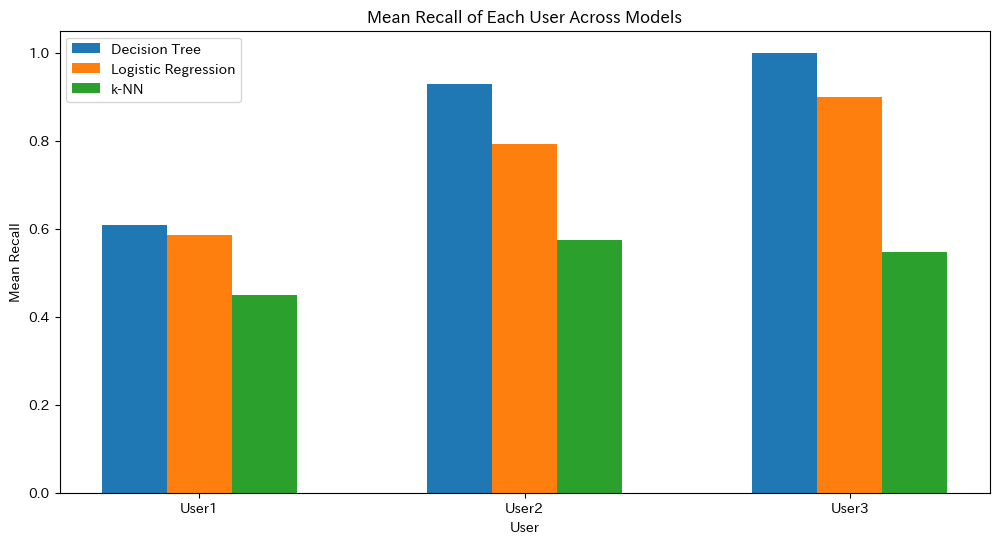

In [195]:
# 事前に定義されたresults辞書を使用して各スコアの平均値を計算し、出力
for user_name in user_names:
    print(user_name)
    for model_name in model_names:
        mean_accuracy = np.mean(results[user_name][model_name]["Accuracy"])
        mean_precision = np.mean(results[user_name][model_name]["Precision"])
        mean_recall = np.mean(results[user_name][model_name]["Recall"])
        mean_f1 = np.mean(results[user_name][model_name]["F1"])
        
        print(f"{model_name}\nMean Accuracy: {mean_accuracy}, Mean Precision: {mean_precision}, Mean Recall: {mean_recall}, Mean_F1: {mean_f1}\n")

# X軸の位置
index = np.arange(len(user_names))
# 棒グラフの設定
bar_width = 0.2

# 各ユーザーの適合率をプロット
plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_names):
    user_precision = [np.mean(results[user][model_name]['Precision']) for user in user_names]
    plt.bar(index + bar_width * i, user_precision, bar_width, label=model_name)

plt.xlabel('User')
plt.ylabel('Mean Precision')
plt.title('Mean Precision of Each User Across Models')
plt.xticks(index + bar_width, user_names)
plt.legend()
plt.show()

# 各ユーザーの再現率をプロット
plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_names):
    user_recall = [np.mean(results[user][model_name]['Recall']) for user in user_names]
    plt.bar(index + bar_width * i, user_recall, bar_width, label=model_name)

plt.xlabel('User')
plt.ylabel('Mean Recall')
plt.title('Mean Recall of Each User Across Models')
plt.xticks(index + bar_width, user_names)
plt.legend()
plt.show()

### 結果
- 決定木は, ロジスティック回帰やk-NNよりも, 性能が良かった.

## 5. シャピロ・ウィルク検定
### 目的
-  得られた適合率データ群が正規分布に従っているかどうかを確認するため.

In [201]:
from scipy import stats

def shapiro(user_name):
    # 検定の実施
    w_stat, p_value = stats.shapiro(results[user_name]["Decision Tree"]["Precision"])

    print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")

for user_name in user_names:    
    print(user_name)
    shapiro(user_name)
    print("\n")

User1
検定結果: 統計量 = 0.8820337653160095, p値 = 0.13769054412841797


User2
検定結果: 統計量 = 1.0, p値 = 1.0


User3
検定結果: 統計量 = 0.3657206892967224, p値 = 1.0036932707180313e-07




### 結果
- 決定木モデルでは, User3に対する適合率データ群のp値が0.05以下であったため, 正規分布に従っていないと言える.つまり, ノンパラメトリックな検定を使うべきだということが分かる.

## 6. ウィルコクソンの符号順位検
### 目的
- 片側検定を使って, 決定木を用いた手法と他の手法の適合率に有意差があるかどうか(決定木を用いた手法の方が有効かどうか)を調べるため.

In [199]:
def wilcoxon(user_name, other_precisions):
    # 検定の実施
    w_stat, p_value = stats.wilcoxon(results[user_name]["Decision Tree"]["Precision"], other_precisions, alternative='greater')

    print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")
    print("\n")
    
for user_name in user_names:
    print(user_name)
    wilcoxon(user_name, results[user_name]["Random"]["Precision"])

User1
検定結果: 統計量 = 41.0, p値 = 0.014200918522100847


User2
検定結果: 統計量 = 55.0, p値 = 0.0009765625


User3
検定結果: 統計量 = 55.0, p値 = 0.0009765625




In [200]:
# 決定木と他の手法（k-NN、ロジスティック回帰）の適合率に有意差があるかを調べる
for user_name in user_names:
    print(f"Results for {user_name}:")
    
    # ロジスティック回帰の適合率
    logistic_precisions = results[user_name]['Logistic Regression']['Precision']
    print("決定木 vs ロジスティック回帰")
    wilcoxon(user_name, logistic_precisions)

    # k-NNの適合率
    knn_precisions = results[user_name]['k-NN']['Precision']
    print("決定木 vs k-NN")
    wilcoxon(user_name, knn_precisions)


Results for User1:
決定木 vs ロジスティック回帰
検定結果: 統計量 = 17.0, p値 = 0.3060449400446284


決定木 vs k-NN
検定結果: 統計量 = 37.0, p値 = 0.042915479222142824


Results for User2:
決定木 vs ロジスティック回帰
検定結果: 統計量 = 36.0, p値 = 0.00575691403842271


決定木 vs k-NN
検定結果: 統計量 = 55.0, p値 = 0.0009765625


Results for User3:
決定木 vs ロジスティック回帰
検定結果: 統計量 = 6.0, p値 = 0.35750032734404463


決定木 vs k-NN
検定結果: 統計量 = 36.0, p値 = 0.00575691403842271




## 結果
- 全てのユーザーにおいて, p値が0.05以下であったため, 有意水準5%で決定木を用いた手法とランダム手法の適合率に有意差があった. つまり, 決定木を用いた手法の方が有効であることが分かる.